### Test - Legacy small box comparisons
</b> Author:   </b>  Sam MacKay

### Import relevant files:

In [1]:
import sys
import os

try:
    current_file = os.path.realpath(__file__)
except NameError:
    # __file__ not defined
    if sys.argv[0]:  # Might still work in some IDEs
        current_file = os.path.realpath(sys.argv[0])
    else:
        # Fallback to current working directory (e.g. Jupyter)
        current_file = os.getcwd()

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.path.dirname(current_file), '../..'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

import legacy.full_solver as s
import utils.handle_filetypes as utilIO

importlib.reload(fs)
importlib.reload(rtm)
importlib.reload(utilIO)

import numpy as np
import matplotlib.pyplot as plt

Setting top level path for imports: /home/administrator/Programs/synthPy/src

Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]


<module 'processing.diagnostics' from '/home/administrator/Programs/synthPy/src/processing/diagnostics.py'>

To use the ray tracer, first create a 'domain', load the domain with an electron distribution, calculate electron gradients, initialise a beam, and solve!
\
\
The output can either be plotted, or passed further through ray optics for synthetic diagnostics

In [2]:
extent_x = 5e-4
extent_y = 5e-4
extent_z = 10e-3

n_cells = 128

ne_x = np.linspace(-extent_x,extent_x, n_cells)
ne_y = np.linspace(-extent_y,extent_y, n_cells)
ne_z = np.linspace(-extent_z,extent_z, n_cells)

probing_extent = extent_z
probing_direction = 'z'

# define beam parameters
wl = 1064e-9
probing_direction = 'z'
beam_size = [extent_x, extent_y]    # beam radius
probing_extent = extent_z
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
divergence = 0.05e-3

slab = fs.ScalarDomain(ne_x, ne_y, ne_z, ne_extent)
slab.test_exponential_cos(n_e0 = 2e17 * 1e6, Ly = 1e-3, s = -4e-3)
slab.calc_dndr(lwl)

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982192993164062 GB
 - free  : 3.5065765380859375 GB
 - used  : 11.502540588378906 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...
Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982192993164062 GB
 - free  : 3.4013748168945312 GB
 - used  : 11.599937438964844 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


Solve gradients, initialise beam, and solve

In [3]:
## Initialise rays and solve
s0 = fs.init_beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

slab.solve(s0)
rf = slab.rf


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 712 B): 135.80322265625 MB
 --> Np = 200000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 16 cores.
NamedSharding(mesh=Mesh('rows': 16, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.00035309791564941406 secondsTrue
True
True

Completed ray trace in 5.302 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (200000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the 

In [ ]:
from processing.plotting import general_ray_plots

l_x = 0
u_x = 0.3
l_y = -5
u_y = 5

In [ ]:
graph_domain(slab)

print("Completed updated ray trace in {} seconds for {} rays in a {}^3 domain.".format(slab.duration, Np, M_V))

## Plot
general_ray_plots(rf, M_V, lwl, l_x = l_x, u_x = u_x, l_y = l_y, u_y = u_y)

In [ ]:
from shared.propagation import ray_to_Jonesvector

rf_updated_raw, _ = ray_to_Jonesvector(beam_definition.s0, keep_current_plane = True)
rf_legacy_raw, _ = ray_to_Jonesvector(s0, keep_current_plane = True)
s
general_ray_plots(rf_updated_raw, M_V, lwl, l_x = l_x, u_x = u_x, l_y = l_y, u_y = u_y)
general_ray_plots(rf_legacy_raw, M_V, lwl, l_x = l_x, u_x = u_x, l_y = l_y, u_y = u_y)

Text(0, 0.5, 'e- density')

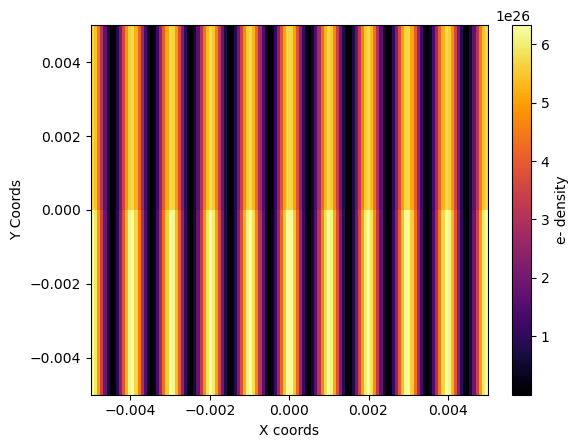

In [4]:
xy = domain.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain.x[0], domain.x[-1], domain.y[0], domain.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')


200000 rays received, 126973 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126973. 126973.]
rf after clearing nan's: [126973. 126973.]


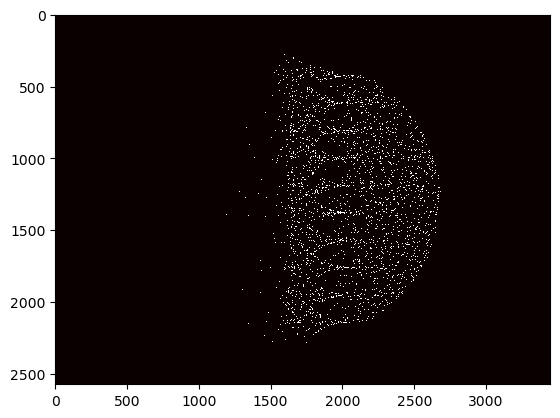

In [5]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

#plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126973 incident on the first lens.
 --> 36.5 % of rays wasted!


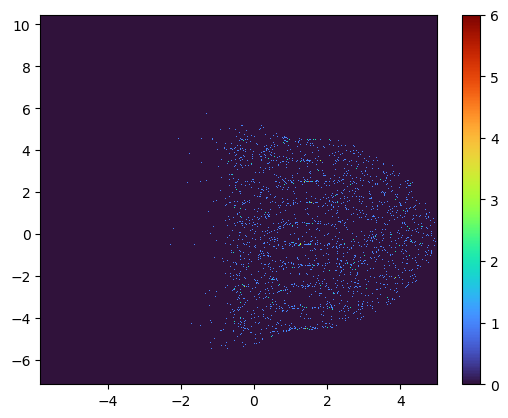

In [8]:
converter = diag.Refractometry(lwl, rf)
rf_mm = converter.r0
del converter

from shared.utils import heat_plot
heat_plot(rf_mm[0], rf_mm[2])

Pass through ray optics: For Shadowgaphy, Schlieren, or Refractometry:


200000 rays received, 126973 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126973. 126973.]
rf after clearing nan's: [126971. 126971.]


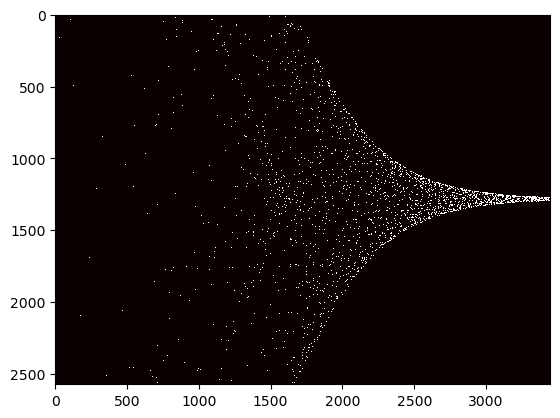

In [11]:
refractometer = diag.Refractometry(lwl, rf)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126973 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126973. 126973.]
rf after clearing nan's: [126973. 126973.]


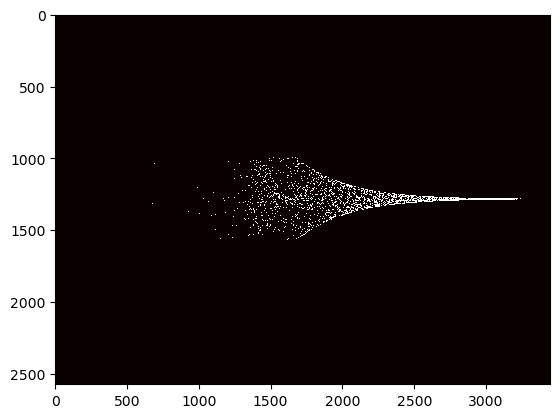

In [14]:
refractometer = diag.Refractometry(lwl, rf, L = 50)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))

In [ ]:
shadowgrapher = diag.Shadowgraphy(lwl, rf)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


200000 rays received, 126973 incident on the first lens.
 --> 36.5 % of rays wasted!

rf size expected: [126973. 126973.]
rf after clearing nan's: [76504. 76504.]


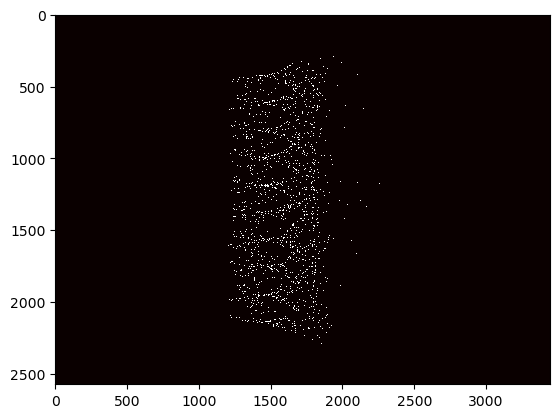

In [20]:
schlierener = diag.Schlieren(lwl, rf)
schlierener.DF_solve()
schlierener.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))